
XRD_data\A_17-09-26
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty
-------------------------------------------------------------------------------------
   1    41.7138   ±  0.0018          739    2.16355   ± 0.00009
   2    48.5482   ±  0.0027          365    1.87374   ± 0.00010
   3    71.0812   ±  0.0048          176    1.32518   ± 0.00008
   4    85.9070   ±  0.0051          184    1.13046   ± 0.00005
   5    90.7545   ±  0.0140           46    1.08227   ± 0.00013

Goodness of fit:
χ² = 3979.06
Degrees of freedom = 1984
Reduced χ² = 2.006

XRD_data\A_17-09-26_2
Peak   2θ (°)       ± uncertainty     Intensity       d (Å)      ± uncertainty
-------------------------------------------------------------------------------------
   1    41.7160   ±  0.0017          761    2.16344   ± 0.00009
   2    48.5479   ±  0.0027          381    1.87375   ± 0.00010
   3    71.0743   ±  0.0045          187    1.32529   ± 0.00007
   4    85.9244   ±  0.0050          1

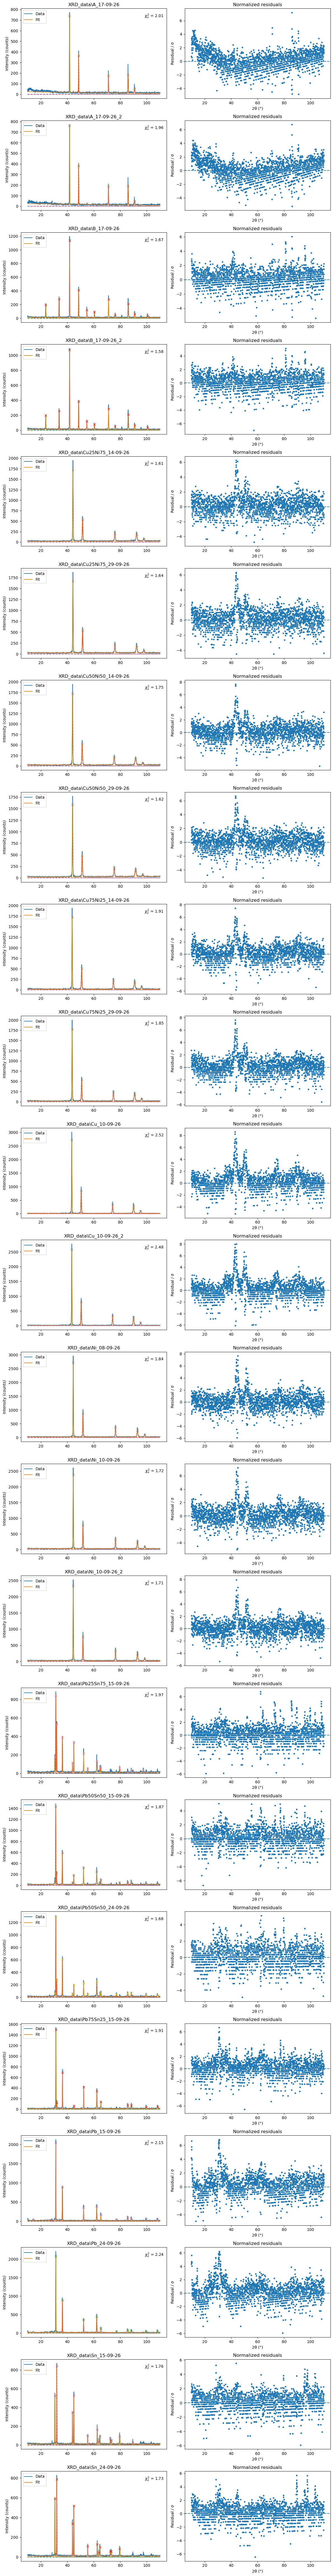

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from glob import glob

files = sorted(glob("XRD_data/*.UXD"))

fig, axes = plt.subplots(
    len(files), 2,
    figsize=(12, 4 * len(files))
)

if len(files) == 1:
    axes = np.array([axes])

data_axes = axes[:, 0]
residual_axes = axes[:, 1]

peak_angles = {}
peak_intensities = {}
peak_d = {}
peak_angle_errors = {}
peak_d_errors = {}


# ---------------------------------------------------------
# Gaussian functions
# ---------------------------------------------------------

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def gaussian_sum(x, *params):

    # First two parameters are the linear background
    m = params[0]
    b = params[1]

    y = m * x + b

    # Remaining parameters are the Gaussian peaks
    for i in range(2, len(params), 3):

        A = params[i]
        mu = params[i + 1]
        sigma = params[i + 2]

        y += gaussian(x, A, mu, sigma)

    return y


# ---------------------------------------------------------
# Bragg's law
# ---------------------------------------------------------

wavelength = 1.5406  # Angstrom, Cu K_alpha
n = 1


for i, file in enumerate(files):

    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------

    data = np.loadtxt(file)

    twotheta = data[:, 0]
    intensity = data[:, 1]

    # Uncertainty from counting statistics
    intensity_error = np.sqrt(np.maximum(intensity, 1))


    # -----------------------------------------------------
    # Step 1: Find rough peak positions
    # -----------------------------------------------------

    peaks, _ = find_peaks(
        intensity,
        prominence=50
    )

    rough_positions = twotheta[peaks]
    rough_heights = intensity[peaks]


    # -----------------------------------------------------
    # Step 2: Initial guesses
    # -----------------------------------------------------

    initial_guess = [
        0,                  # background slope
        np.min(intensity)   # background intercept
    ]

    for position, height in zip(rough_positions, rough_heights):

        initial_guess.extend([
            height,      # amplitude
            position,    # center
            0.15         # sigma
        ])


    # -----------------------------------------------------
    # Step 3: Bounds
    # -----------------------------------------------------

    lower_bounds = [
        -np.inf,    # background slope
        0           # background intercept
    ]

    upper_bounds = [
        np.inf,
        np.inf
    ]

    for position in rough_positions:

        lower_bounds.extend([
            0,
            position - 1.0,
            0.01
        ])

        upper_bounds.extend([
            np.inf,
            position + 1.0,
            1.0
        ])


    # -----------------------------------------------------
    # Step 4: Fit
    # -----------------------------------------------------

    try:

        popt, pcov = curve_fit(
            gaussian_sum,
            twotheta,
            intensity,
            p0=initial_guess,
            sigma=intensity_error,
            absolute_sigma=True,
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )

        # Parameter uncertainties
        perr = np.sqrt(np.diag(pcov))

        fit_success = True

    except (RuntimeError, ValueError):

        print("Fit failed for:", file)

        fit_success = False


    # -----------------------------------------------------
    # Store fitted peak information
    # -----------------------------------------------------

    name = file.split("/")[-1].replace(".UXD", "")

    if fit_success:

        fitted_angles = []
        fitted_intensities = []
        fitted_d = []
        fitted_angle_errors = []
        fitted_d_errors = []


        # -------------------------------------------------
        # Calculate fit
        # -------------------------------------------------

        fit = gaussian_sum(
            twotheta,
            *popt
        )


        # -------------------------------------------------
        # Calculate residuals
        # -------------------------------------------------

        residuals = intensity - fit

        normalized_residuals = (
            residuals / intensity_error
        )


        # -------------------------------------------------
        # Chi squared
        # -------------------------------------------------

        chi_squared = np.sum(
            (residuals / intensity_error)**2
        )

        N = len(intensity)

        # 2 background parameters + 3 per peak
        n_parameters = len(popt)

        degrees_of_freedom = (
            N - n_parameters
        )

        reduced_chi_squared = (
            chi_squared / degrees_of_freedom
        )


        # -------------------------------------------------
        # Store peak parameters
        # -------------------------------------------------

        for j in range(len(rough_positions)):

            # +2 because the first two parameters
            # are the background slope and intercept
            A = popt[2 + 3*j]
            mu = popt[2 + 3*j + 1]
            sigma = popt[2 + 3*j + 2]

            mu_error = perr[2 + 3*j + 1]


            # ---------------------------------------------
            # Bragg's law
            # ---------------------------------------------

            theta = np.radians(mu / 2)

            d = wavelength / (
                2 * np.sin(theta)
            )

            d_error = (
                wavelength
                / (2 * np.sin(theta)**2)
                * np.cos(theta)
                * (np.radians(mu_error) / 2)
            )


            fitted_angles.append(mu)
            fitted_intensities.append(A)
            fitted_d.append(d)
            fitted_angle_errors.append(mu_error)
            fitted_d_errors.append(d_error)


        peak_angles[name] = np.array(fitted_angles)
        peak_intensities[name] = np.array(fitted_intensities)
        peak_d[name] = np.array(fitted_d)
        peak_angle_errors[name] = np.array(fitted_angle_errors)
        peak_d_errors[name] = np.array(fitted_d_errors)


        # -------------------------------------------------
        # Print results
        # -------------------------------------------------

        print("\n" + "=" * 85)
        print(name)
        print("=" * 85)

        print(
            "Peak   2θ (°)       ± uncertainty     "
            "Intensity       d (Å)      ± uncertainty"
        )

        print("-" * 85)

        for j in range(len(fitted_angles)):

            print(
                f"{j+1:4d}   "
                f"{fitted_angles[j]:8.4f}   "
                f"± {fitted_angle_errors[j]:7.4f}   "
                f"{fitted_intensities[j]:10.0f}   "
                f"{fitted_d[j]:8.5f}"
                f"   ± {fitted_d_errors[j]:7.5f}"
            )


        # -------------------------------------------------
        # Print goodness of fit
        # -------------------------------------------------

        print("\nGoodness of fit:")
        print(f"χ² = {chi_squared:.2f}")
        print(f"Degrees of freedom = {degrees_of_freedom}")
        print(f"Reduced χ² = {reduced_chi_squared:.3f}")


        # -------------------------------------------------
        # Plot original data
        # -------------------------------------------------

        data_axes[i].plot(
            twotheta,
            intensity,
            label="Data"
        )


        # -------------------------------------------------
        # Plot total Gaussian + background fit
        # -------------------------------------------------

        data_axes[i].plot(
            twotheta,
            fit,
            label="Fit"
        )


        # -------------------------------------------------
        # Plot individual Gaussians
        # -------------------------------------------------

        for j in range(len(rough_positions)):

            A = popt[2 + 3*j]
            mu = popt[2 + 3*j + 1]
            sigma = popt[2 + 3*j + 2]

            component = gaussian(
                twotheta,
                A,
                mu,
                sigma
            )

            data_axes[i].plot(
                twotheta,
                component,
                "--",
                alpha=0.5
            )


        # -------------------------------------------------
        # Plot fitted centers
        # -------------------------------------------------

        data_axes[i].plot(
            fitted_angles,
            fitted_intensities,
            "x"
        )


        data_axes[i].set_ylabel(
            "Intensity (counts)"
        )

        data_axes[i].set_title(name)

        data_axes[i].text(
            0.98, 0.95,
            f"$\\chi^2_\\nu$ = {reduced_chi_squared:.2f}",
            transform=data_axes[i].transAxes,
            ha="right",
            va="top"
        )

        data_axes[i].legend()


        # -------------------------------------------------
        # Plot residuals
        # -------------------------------------------------

        residual_axes[i].plot(
            twotheta,
            normalized_residuals,
            "."
        )

        residual_axes[i].axhline(
            0,
            linestyle="--"
        )

        residual_axes[i].set_xlabel(
            "2θ (°)"
        )

        residual_axes[i].set_ylabel(
            "Residual / σ"
        )

        residual_axes[i].set_title(
            "Normalized residuals"
        )


    else:

        data_axes[i].plot(
            twotheta,
            intensity
        )

        data_axes[i].set_ylabel(
            "Intensity (counts)"
        )

        data_axes[i].set_title(name)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

plt.tight_layout()
plt.show()

In [2]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

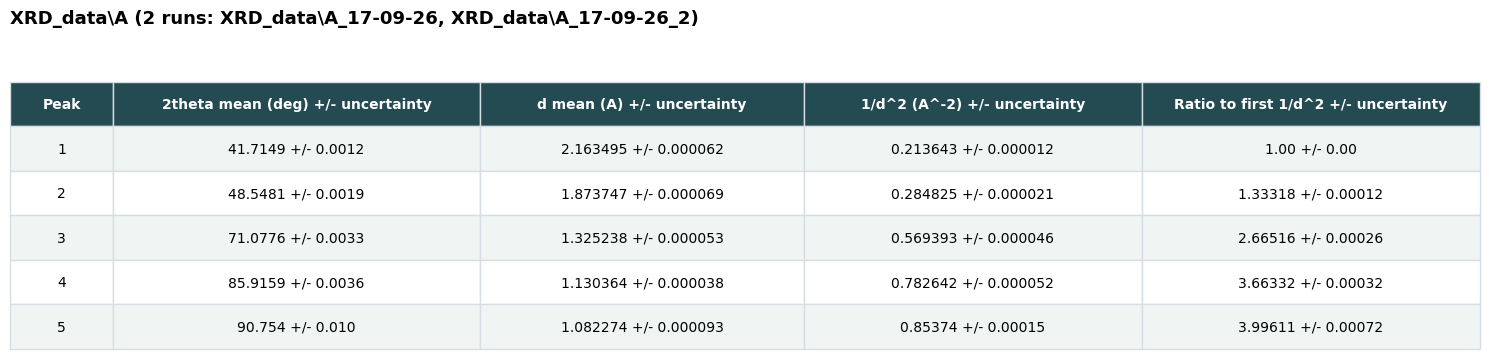

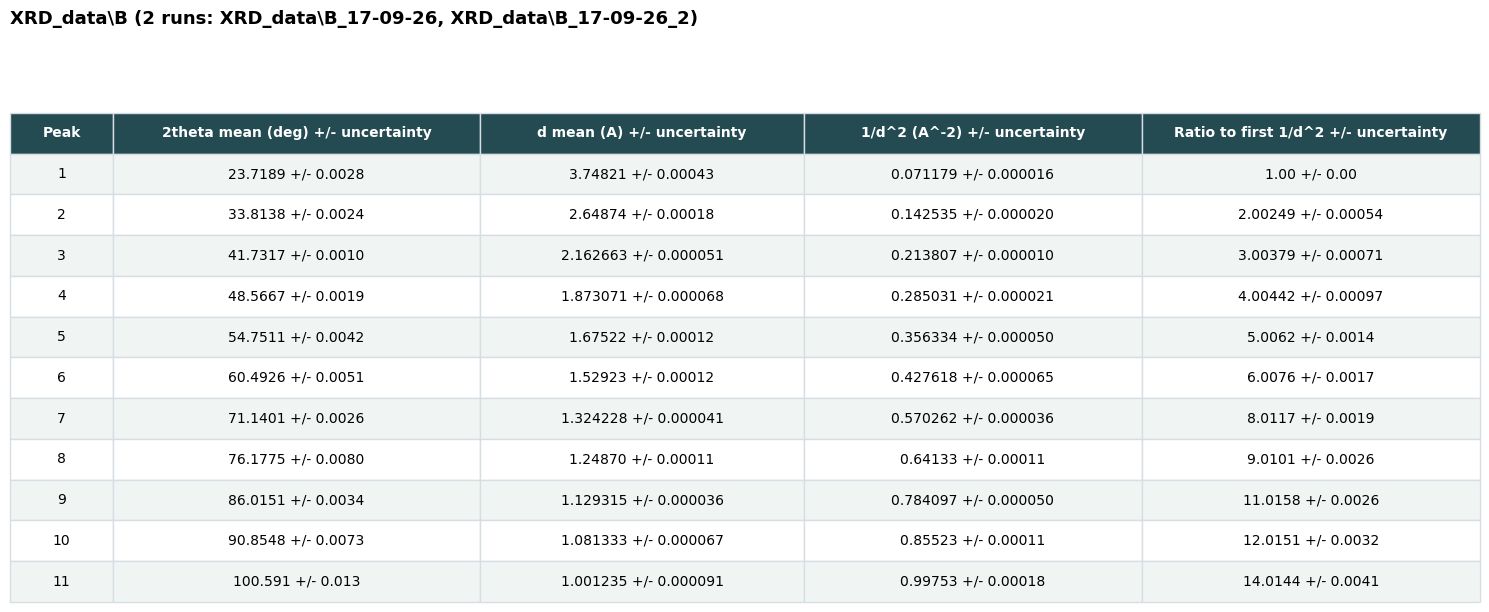

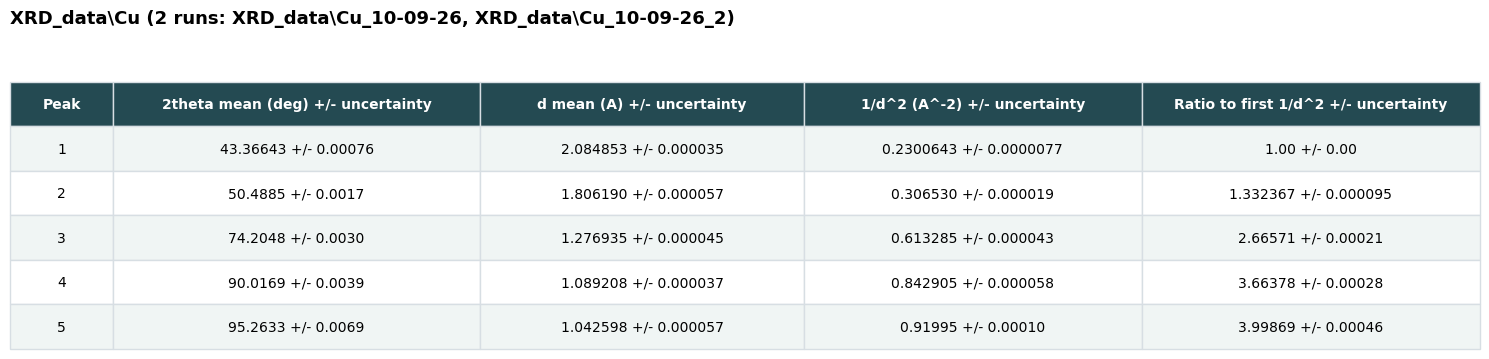

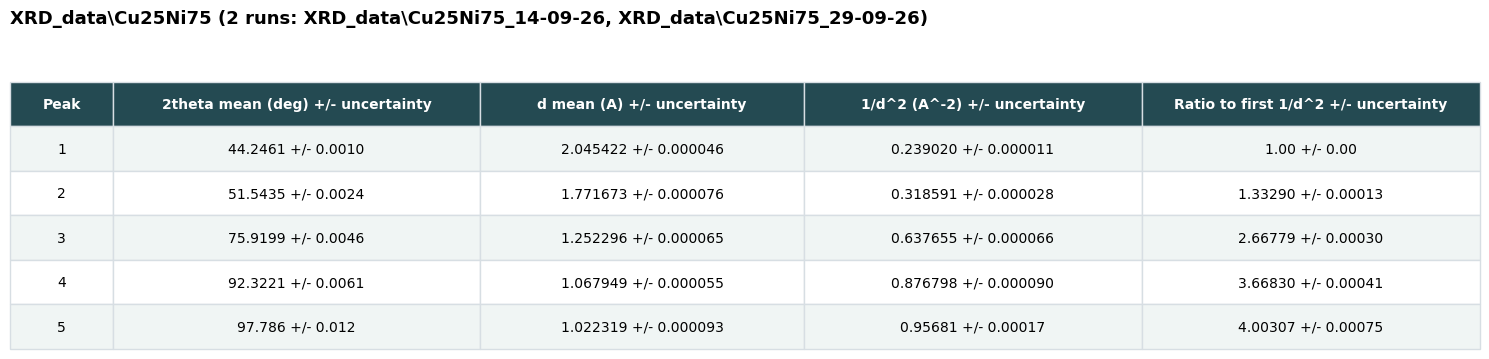

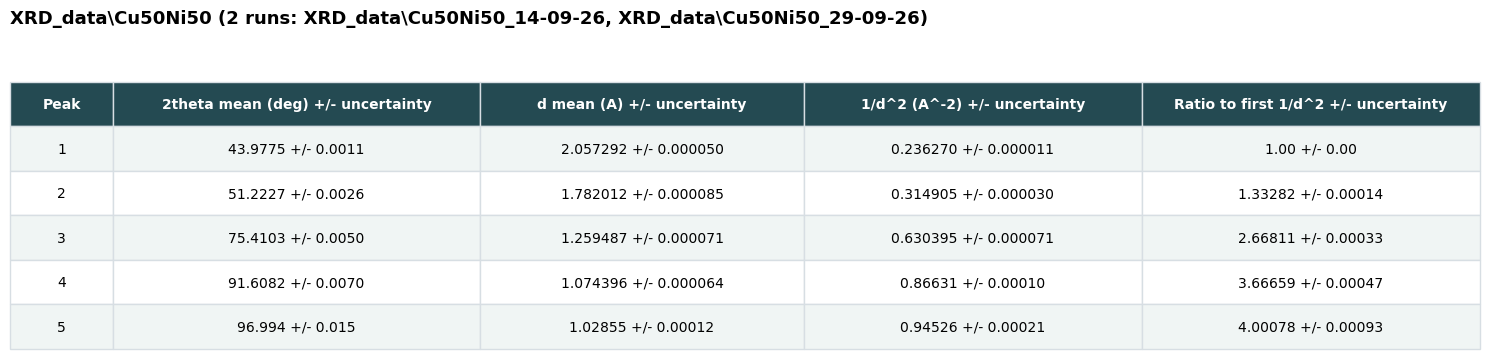

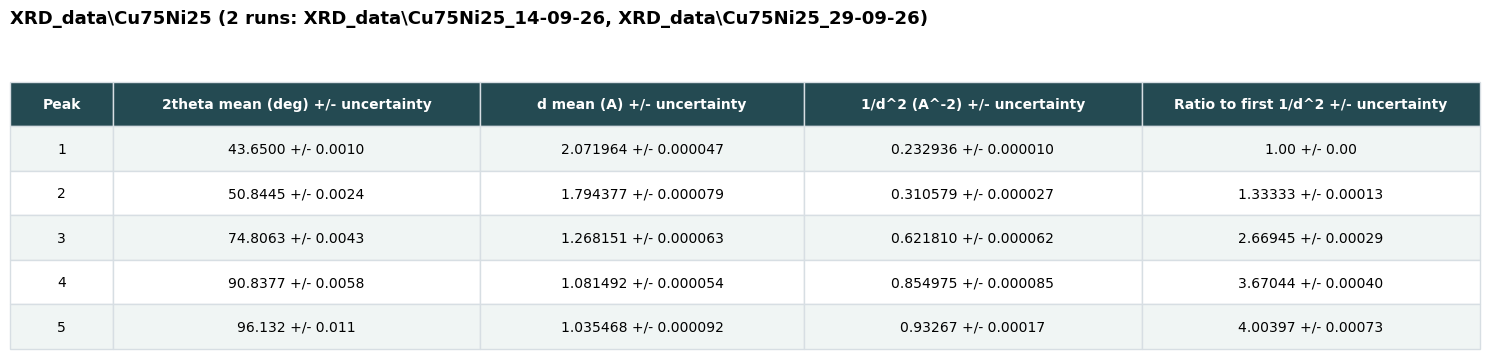

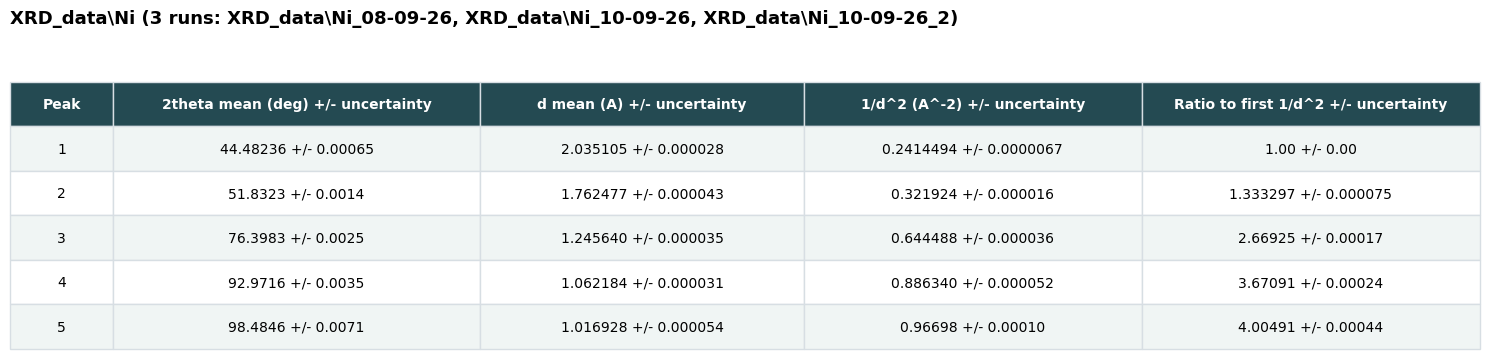

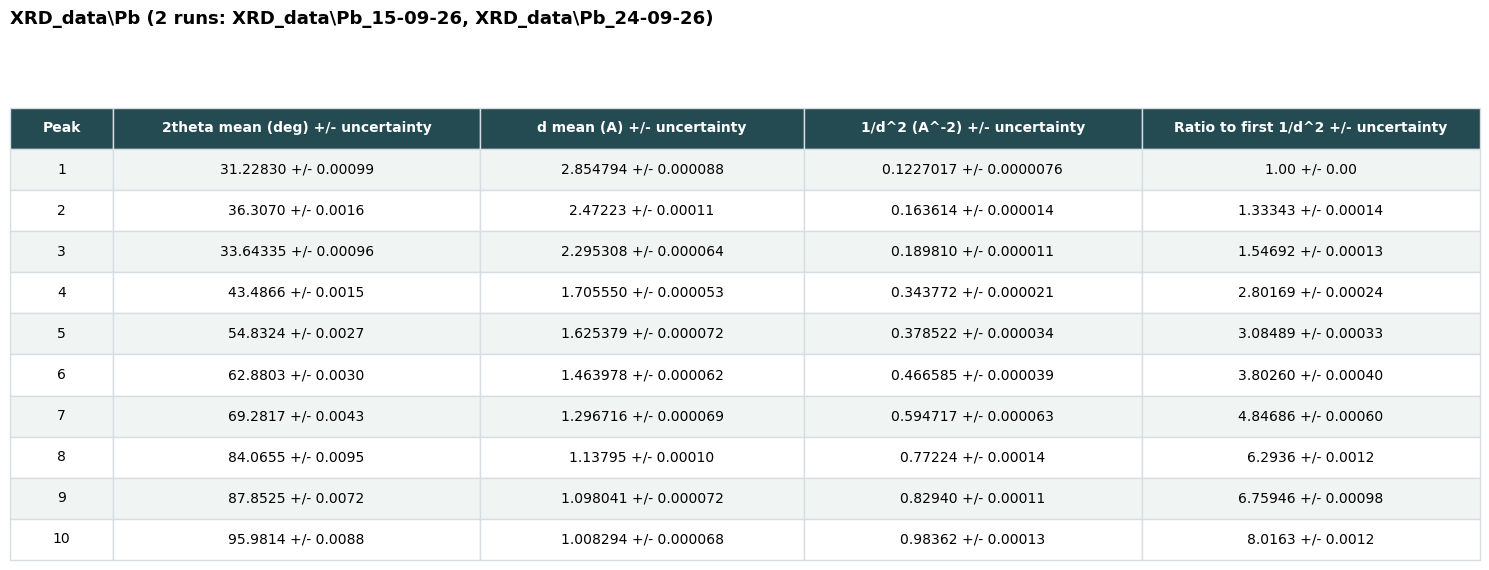

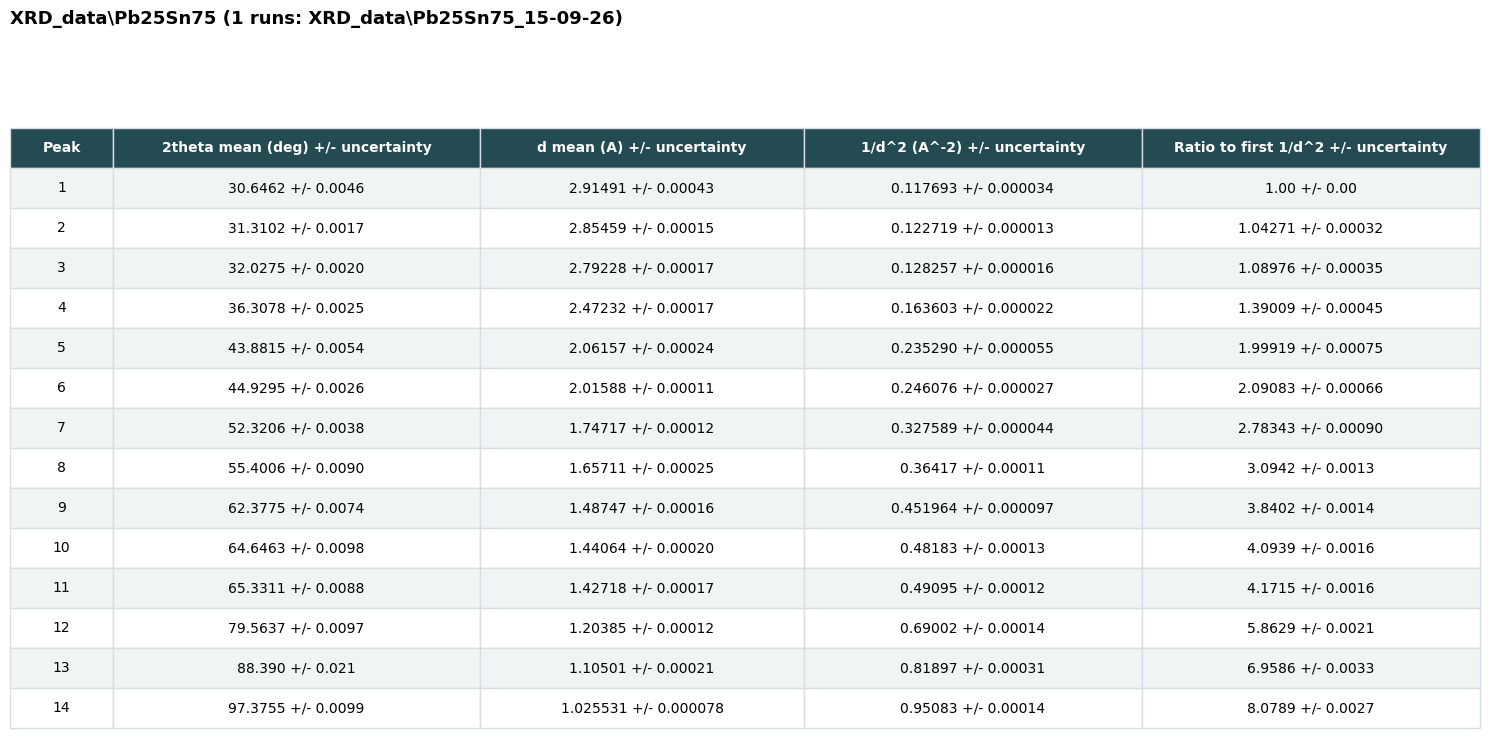

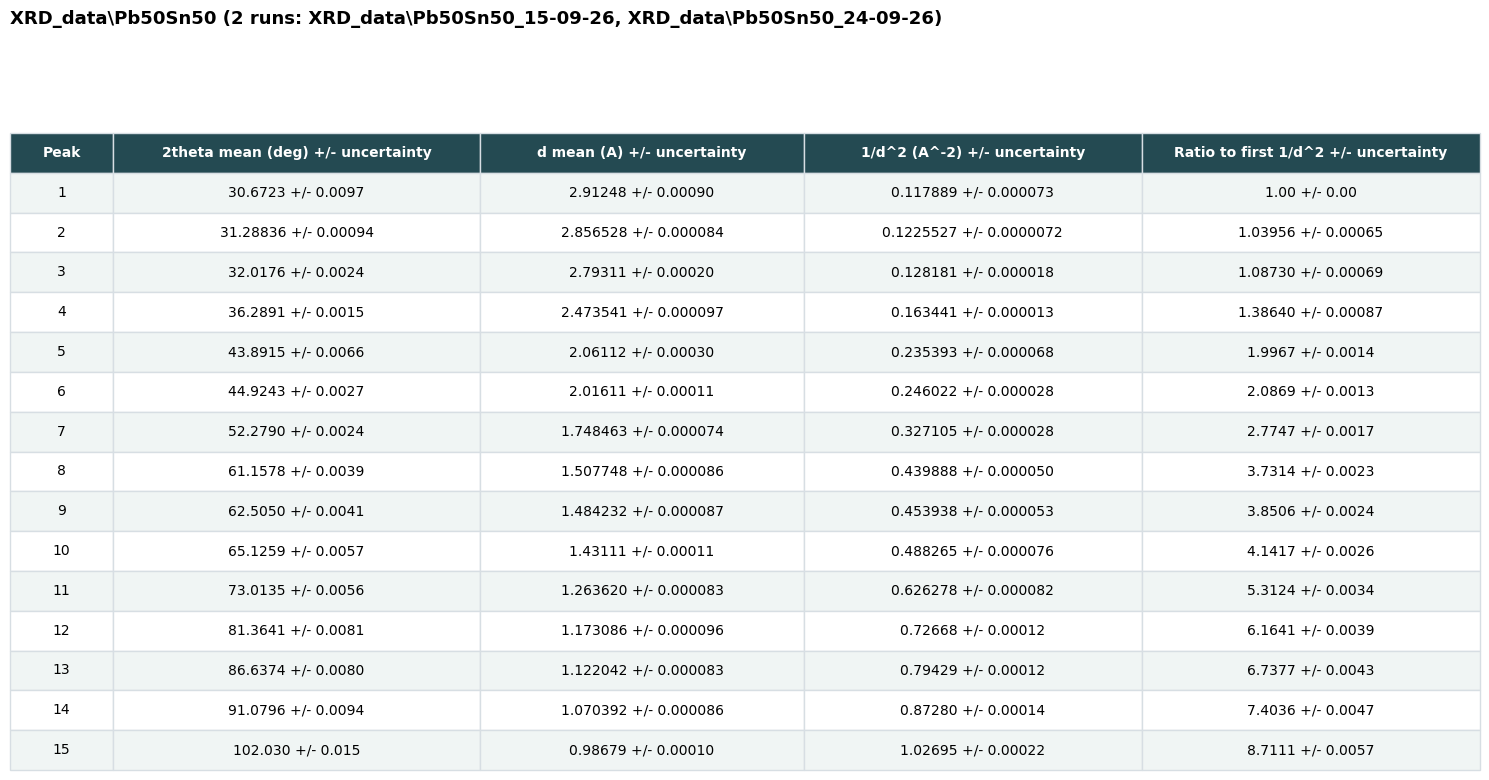

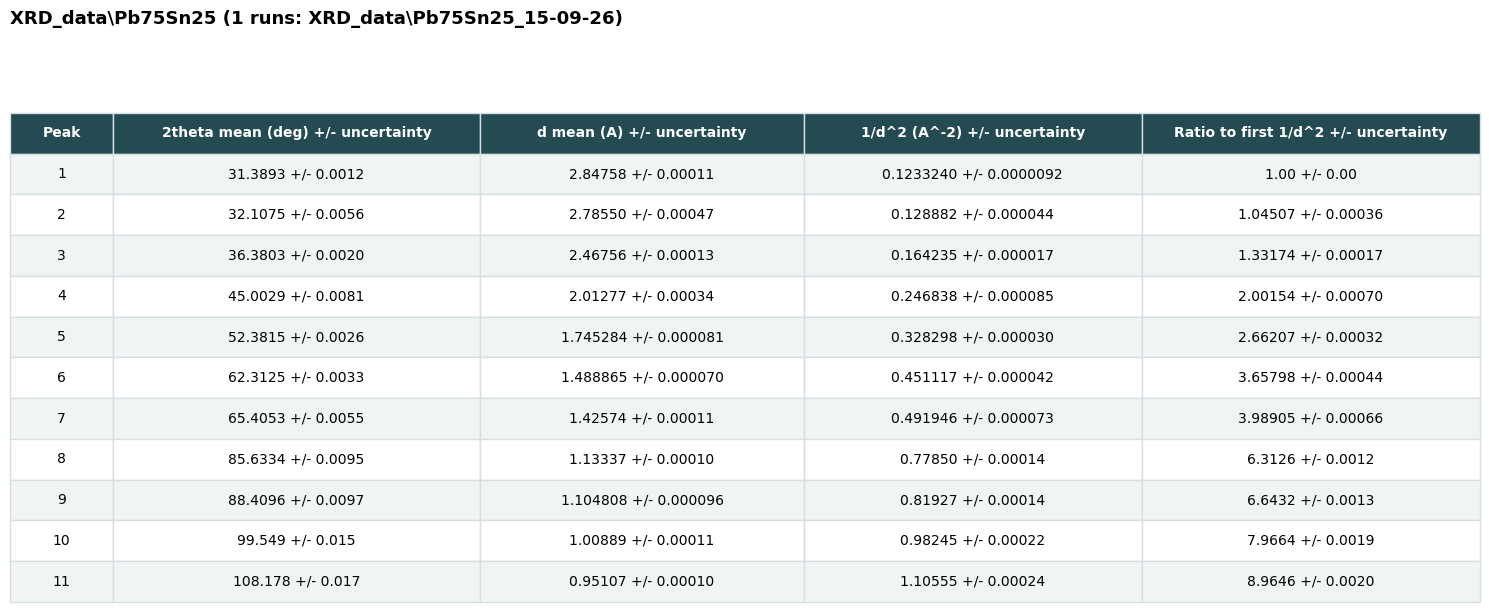

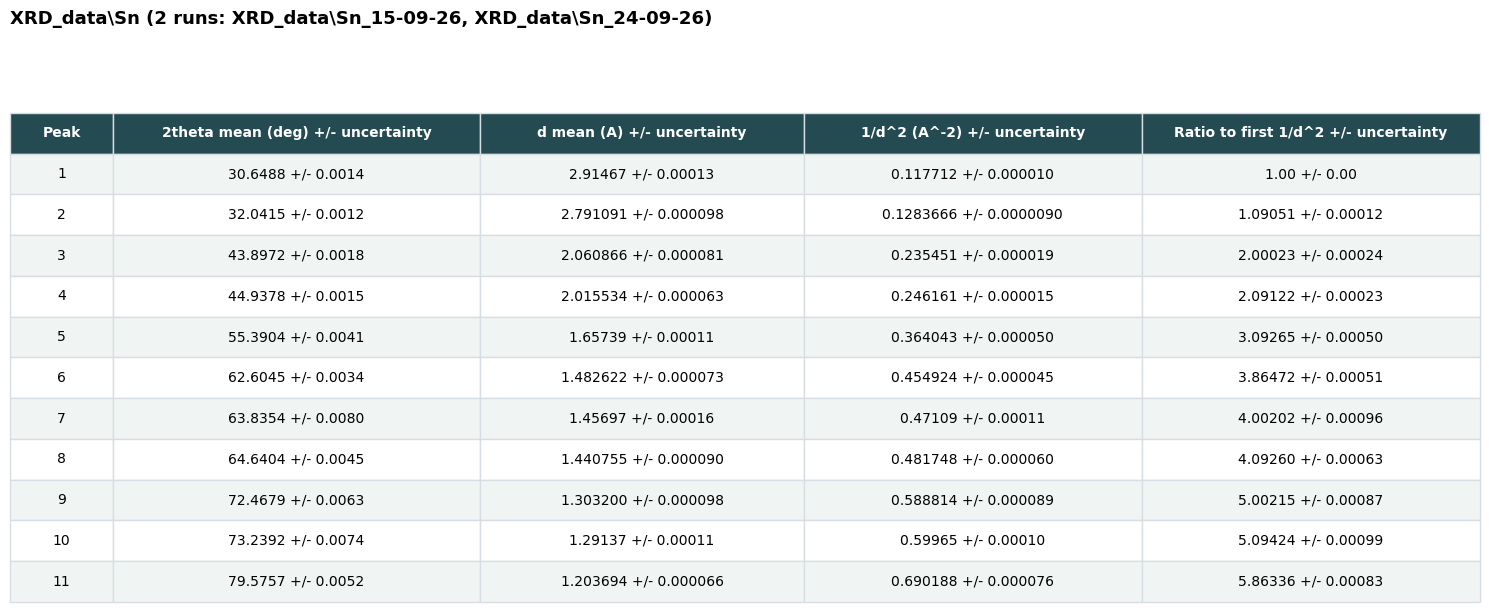

In [3]:
import re
from collections import defaultdict


def weighted_mean_with_uncertainty(values, uncertainties):
    values = np.asarray(values, dtype=float)
    uncertainties = np.asarray(uncertainties, dtype=float)
    valid = (
        np.isfinite(values)
        & np.isfinite(uncertainties)
        & (uncertainties > 0)
    )
    values = values[valid]
    uncertainties = uncertainties[valid]

    if len(values) == 0:
        return np.nan, np.nan

    weights = 1 / uncertainties**2
    mean = np.sum(weights * values) / np.sum(weights)
    uncertainty = 1 / np.sqrt(np.sum(weights))
    return mean, uncertainty


def format_value_uncertainty(value, uncertainty, significant_figures=2):
    value = float(value)
    uncertainty = float(uncertainty)
    if not np.isfinite(value) or not np.isfinite(uncertainty):
        return f"{value} +/- {uncertainty}"
    if uncertainty == 0:
        return f"{value:.2f} +/- 0.00"

    exponent = int(np.floor(np.log10(abs(uncertainty))))
    decimal_places = significant_figures - 1 - exponent
    rounded_uncertainty = round(uncertainty, decimal_places)
    if rounded_uncertainty >= 10 ** (exponent + 1):
        exponent += 1
        decimal_places -= 1

    if decimal_places >= 0:
        return (
            f"{value:.{decimal_places}f} +/- "
            f"{uncertainty:.{decimal_places}f}"
        )

    scale = 10.0**exponent
    mantissa_places = significant_figures - 1
    return (
        f"{value / scale:.{mantissa_places}f}e{exponent:+d} +/- "
        f"{uncertainty / scale:.{mantissa_places}f}e{exponent:+d}"
    )


runs_by_sample = defaultdict(list)
for run_name in peak_angles:
    sample_name = re.sub(r"_\d{2}-\d{2}-\d{2}(?:_\d+)?$", "", run_name)
    runs_by_sample[sample_name].append(run_name)

average_results = {}
for sample_name, run_names in sorted(runs_by_sample.items()):
    # Peaks are stored in increasing 2theta order, so matching uses peak index.
    peak_count = min(len(peak_angles[name]) for name in run_names)
    two_theta_means = []
    two_theta_uncertainties = []
    d_means = []
    d_uncertainties = []

    for peak_index in range(peak_count):
        two_theta_mean, two_theta_uncertainty = weighted_mean_with_uncertainty(
            [peak_angles[name][peak_index] for name in run_names],
            [peak_angle_errors[name][peak_index] for name in run_names],
        )
        d_mean, d_uncertainty = weighted_mean_with_uncertainty(
            [peak_d[name][peak_index] for name in run_names],
            [peak_d_errors[name][peak_index] for name in run_names],
        )
        two_theta_means.append(two_theta_mean)
        two_theta_uncertainties.append(two_theta_uncertainty)
        d_means.append(d_mean)
        d_uncertainties.append(d_uncertainty)

    inverse_d_squared = 1 / np.asarray(d_means)**2
    inverse_d_squared_uncertainties = (
        2 * np.asarray(d_uncertainties) / np.asarray(d_means)**3
    )
    ratio_to_first = inverse_d_squared / inverse_d_squared[0]
    ratio_uncertainties = np.zeros_like(ratio_to_first)
    ratio_uncertainties[1:] = np.abs(ratio_to_first[1:]) * np.sqrt(
        (inverse_d_squared_uncertainties[1:] / inverse_d_squared[1:])**2
        + (inverse_d_squared_uncertainties[0] / inverse_d_squared[0])**2
    )

    average_results[sample_name] = {
        "runs": run_names,
        "two_theta": np.asarray(two_theta_means),
        "two_theta_uncertainty": np.asarray(two_theta_uncertainties),
        "d": np.asarray(d_means),
        "d_uncertainty": np.asarray(d_uncertainties),
        "inverse_d_squared": inverse_d_squared,
        "inverse_d_squared_uncertainty": inverse_d_squared_uncertainties,
        "ratio_to_first": ratio_to_first,
        "ratio_to_first_uncertainty": ratio_uncertainties,
    }

    table_rows = [
        [
            str(peak_index + 1),
            format_value_uncertainty(angle, angle_error),
            format_value_uncertainty(spacing, spacing_error),
            format_value_uncertainty(inv_d2, inv_d2_error),
            format_value_uncertainty(ratio, ratio_error),
        ]
        for peak_index, (
            angle,
            angle_error,
            spacing,
            spacing_error,
            inv_d2,
            inv_d2_error,
            ratio,
            ratio_error,
        ) in enumerate(zip(
            two_theta_means,
            two_theta_uncertainties,
            d_means,
            d_uncertainties,
            inverse_d_squared,
            inverse_d_squared_uncertainties,
            ratio_to_first,
            ratio_uncertainties,
        ))
    ]

    fig, ax = plt.subplots(figsize=(15, max(2.5, 0.42 * len(table_rows) + 1.6)))
    ax.axis("off")
    ax.set_title(
        f"{sample_name} ({len(run_names)} runs: {', '.join(run_names)})",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=16,
    )
    table = ax.table(
        cellText=table_rows,
        colLabels=[
            "Peak",
            "2theta mean (deg) +/- uncertainty",
            "d mean (A) +/- uncertainty",
            "1/d^2 (A^-2) +/- uncertainty",
            "Ratio to first 1/d^2 +/- uncertainty",
        ],
        colWidths=[0.07, 0.25, 0.22, 0.23, 0.23],
        cellLoc="center",
        bbox=[0, 0, 1, 0.88],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor("#D7DEE3")
        if row == 0:
            cell.set_facecolor("#244A52")
            cell.set_text_props(color="white", weight="bold")
        else:
            cell.set_facecolor("#F0F5F4" if row % 2 else "white")

    fig.tight_layout()
    plt.show()

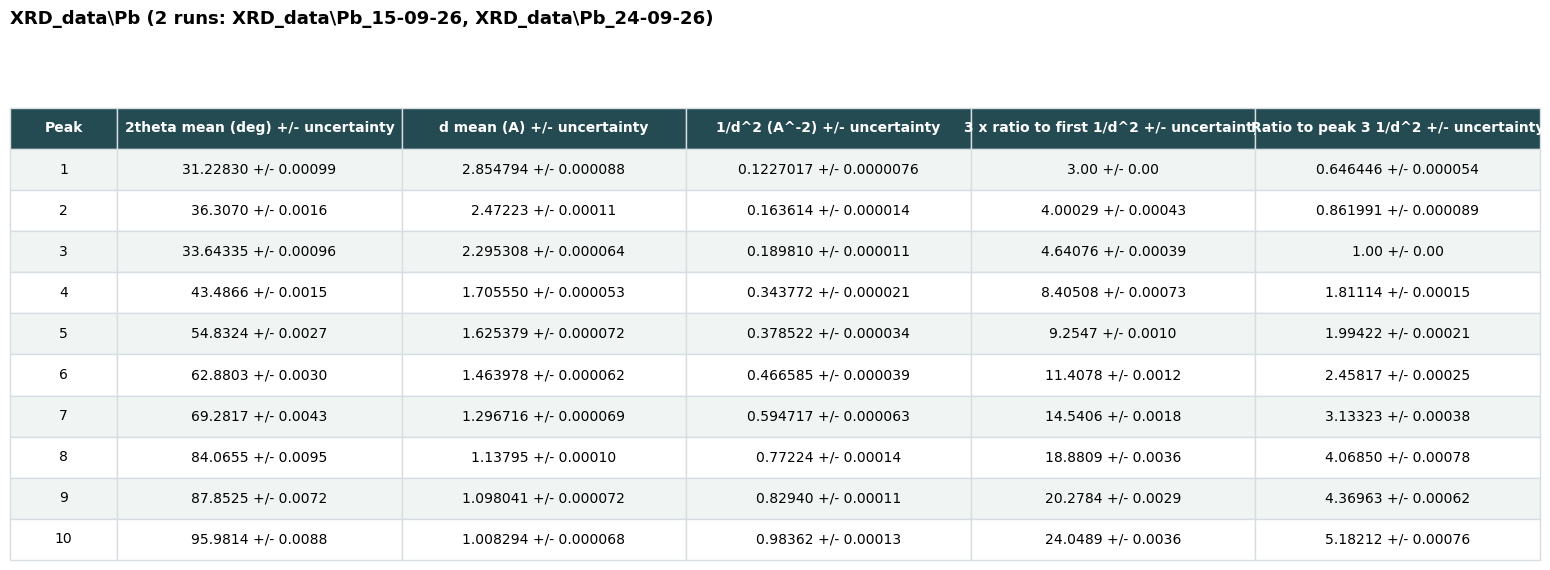

In [7]:
# Work with one sample at a time. Change this to another sample name if needed.
SAMPLE_NAME = "Pb"

sample_key = SAMPLE_NAME if SAMPLE_NAME in average_results else None
if sample_key is None:
    sample_matches = [
        name for name in average_results
        if name.replace("\\", "/").rstrip("/").split("/")[-1] == SAMPLE_NAME
    ]
    if len(sample_matches) != 1:
        available = ", ".join(sorted(average_results))
        if not sample_matches:
            raise KeyError(f"No sample named {SAMPLE_NAME!r}. Available: {available}")
        raise ValueError(
            f"{SAMPLE_NAME!r} matches multiple samples: {sample_matches}. "
            "Set SAMPLE_NAME to the full sample key."
        )
    sample_key = sample_matches[0]

sample = average_results[sample_key]
peak_count = len(sample["two_theta"])
if peak_count < 3:
    raise ValueError(f"{sample_key!r} needs at least three peaks to calculate ratios to peak 3.")

inverse_d_squared = sample["inverse_d_squared"]
inverse_d_squared_uncertainties = sample["inverse_d_squared_uncertainty"]
ratio_to_first_times_three = 3 * sample["ratio_to_first"]
ratio_to_first_times_three_uncertainties = 3 * sample["ratio_to_first_uncertainty"]
ratio_to_third = inverse_d_squared / inverse_d_squared[2]
ratio_to_third_uncertainties = np.abs(ratio_to_third) * np.sqrt(
    (inverse_d_squared_uncertainties / inverse_d_squared)**2
    + (inverse_d_squared_uncertainties[2] / inverse_d_squared[2])**2
)
ratio_to_third[2] = 1.0
ratio_to_third_uncertainties[2] = 0.0

# Add custom columns here; each needs one value per peak.
extra_columns = {}
# Example: extra_columns["d rounded (A)"] = np.round(sample["d"], 3)
for column_name, values in extra_columns.items():
    if len(values) != peak_count:
        raise ValueError(
            f"Column {column_name!r} has {len(values)} values; expected {peak_count}."
        )

metrics = [
    ("2theta mean (deg) +/- uncertainty", "two_theta", "two_theta_uncertainty"),
    ("d mean (A) +/- uncertainty", "d", "d_uncertainty"),
    ("1/d^2 (A^-2) +/- uncertainty", "inverse_d_squared", "inverse_d_squared_uncertainty"),
]
sample_columns = [("Peak", [str(i + 1) for i in range(peak_count)])]
for label, value_key, error_key in metrics:
    sample_columns.append((
        label,
        [
            format_value_uncertainty(value, error)
            for value, error in zip(sample[value_key], sample[error_key])
        ],
    ))
sample_columns.append((
    "3 x ratio to first 1/d^2 +/- uncertainty",
    [
        format_value_uncertainty(value, error)
        for value, error in zip(
            ratio_to_first_times_three,
            ratio_to_first_times_three_uncertainties,
        )
    ],
))
sample_columns.append((
    "Ratio to peak 3 1/d^2 +/- uncertainty",
    [
        format_value_uncertainty(value, error)
        for value, error in zip(ratio_to_third, ratio_to_third_uncertainties)
    ],
))
sample_columns.extend(extra_columns.items())

column_labels = [label for label, _ in sample_columns]
table_rows = [
    [str(values[row]) for _, values in sample_columns]
    for row in range(peak_count)
]
fig, ax = plt.subplots(
    figsize=(max(13, 2.6 * len(column_labels)), max(2.5, 0.42 * peak_count + 1.6))
)
ax.axis("off")
ax.set_title(
    f"{sample_key} ({len(sample['runs'])} runs: {', '.join(sample['runs'])})",
    loc="left", fontsize=13, fontweight="bold", pad=16,
)
column_widths = [0.07] + [0.93 / (len(column_labels) - 1)] * (len(column_labels) - 1)
table = ax.table(
    cellText=table_rows,
    colLabels=column_labels,
    colWidths=column_widths,
    cellLoc="center",
    bbox=[0, 0, 1, 0.88],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("#D7DEE3")
    if row == 0:
        cell.set_facecolor("#244A52")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F0F5F4" if row % 2 else "white")
fig.tight_layout()
plt.show()